## Objective
Objective of this kernel is 
- To bring in a quick reference that covers the key concepts of ML.
- Target Audience: Beginners
- Best way to learn is to learn from the best, this kernel introduces the key personalities of Machine Learning world
- Video tutorials are the best and only next to a class room session, bunch of videos included
- Beyond theory... implementation, validation and evaluation gives significant confidence to the learner. Every progress or new concept is validated as a competition submission 


#### Some of My Other Works
[Game of Thrones - Systematic Analysis of GoT Battles(Kaggle Script of the Week)](https://www.kaggle.com/gowrishankarin/analysis-on-got-battles-kaggle-script-of-the-week)  
[Space and Time Complexity - 5 Governing Rules](https://www.kaggle.com/gowrishankarin/time-and-space-complexity-5-governing-rules)  

## What to expect
This kernel is expected to answer the following questions...
- How to look at data by doing an exploratory data analysis?
- How to handle missing data in a dataset?
- What are numerical and categorical data?
- How to identify numerical and categorical data?
- What are machine learning models?
- How to prepare datasets feed into some of the famous ML models?
- What is Bias and Variance?
- How to handle Bias and Variance?
- What are hyperparameters, how to optimize hyperparameters?
- What are data pipelines?

## <a id='section1'>Inspiration</a>
**The inspiration is to bring in what I learned in Kaggle Learn - Machine Learning Course into One Kernel**

I thought the whole course can be fit into one Jupyter notebook and started building this.
During initial periods of learning, I struggled a lot in bringing in a process. By then there was no such course available and I believe this notebook along with the course will help the beginners significantly.

Further, I have included learning videos from the following channels/ML experts for clarity and depth.

- [Dmitry Ulyanov, HSE - EDA](https://www.youtube.com/watch?v=3Xisy5EsPWA&feature=youtu.be)
- [Socratica - Python Exceptions](https://www.youtube.com/watch?v=nlCKrKGHSSk&feature=youtu.be)
- [Augmented Startups - Decision Trees](https://youtu.be/DCZ3tsQIoGU)
- [Data School - Handling Missing Values](https://youtu.be/fCMrO_VzeL8)
- [ML with Python - Imputing](https://www.youtube.com/watch?v=ENvSybznF_o&feature=youtu.be)
- [Ian Bailey - Kinds of Data](https://www.youtube.com/watch?v=7bsNWq2A5gI&feature=youtu.be)
- [Cristi Vlad - Label Encoding](https://www.youtube.com/watch?v=IffHV_AS_Do&feature=youtu.be)
- [Augmented Startups - Random Forest](https://youtu.be/D_2LkhMJcfY)
- [MIT Open Courseware - Boosting](https://youtu.be/UHBmv7qCey4)
- [Udacity - Split Data](https://youtu.be/oJzDsnPq4vU)
- [Dr.Andrew Ng - Bias and Variance](https://youtu.be/SjQyLhQIXSM)
- [Ritvikmath - Decision Tree Pruning](https://youtu.be/t56Nid85Thg)
- [Siraj Raval - Hyperparameter Optimization](https://youtu.be/ttE0F7fghfk)
- [Mark Weiss, Beeswax - Data Pipelines](https://youtu.be/C6Abv87D5dU)

Thanks to all of them for their awesome content.

This kernel consists of approximately 25-30 steps, that can be reproduced within an hour or 2. **I suggest everyone to program by yourself rather than copy/paste.**
While learning, I could improve from my rank around 4500 to 424 in just 6-8 submissions. 
I felt that was really cool and I should share the same with everyone.

Thanks to **Dan Becker** of Kaggle for his course and insights.
Reference: [Dan Becker's Learn ML Course](https://www.kaggle.com/learn/machine-learning)

### Python Imports
I decided to import the relevant packages/libraries as and when required rather than doing it in the beginning.

1. [Inspiration](#section1)
1. [Reusable Methods - Set 1](#section2)
1. [Exploratory Data Analysis](#section3)

**Preprocessing**
1. [Simple Model - Catch Failures](#section4)
1. [Missing Data - NaN, Null](#section5)
1. [Simple Imputer](#section6)
1. [Predictions - Numeric Data](#section7)
1. [Submission - 1](#section8)
1. [Missed Features - Examination](#section9)
1. [Categorical Features - Label Encoding](#section10)

**Model Building**
1. [Submission - 2](#section11)
1. [Imputing by Strategy](#section12)
1. [Submission 3](#section13)
1. [Random Forest](#section14)
1. [Submission 4](#section15)
1. [XGBoost](#section16)
1. [Submission 5](#section17)
1. [Observations](#section18)

**Key Concepts**
1. [Train and Validation Data Set](#section19)
1. [Underfitting and Overfitting](#section20)
1. [Optimal Tree Structure](#section21)
1. [Model Tuning](#section22)
1. [Partial Dependence Plots](#section23)
1. [Data Pipeline](#section24)
1. [Cross Validation](#section25)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))

# Any results you write to the current directory are saved as output.

['sample_submission.csv', 'train.csv.gz', 'sample_submission.csv.gz', 'test.csv.gz', 'data_description.txt', 'test.csv', 'train.csv']


## <a id='section2'>Reusable Methods - SET 1</a>

We will be using the following methods repeatedly while progressing through the course. I suggest to skip this section and refer as and when it is used for the first time.

In [2]:
def write_submissions(file_name, test_df, predictions):
    test_df.Id = test_df.Id.astype('int32')

    output = pd.DataFrame({
        'Id': test_df.Id, 'SalePrice': predictions
    })
    output.to_csv(file_name, index=False)
    
def get_categorical_columns(data_df):
    return list(data_df.select_dtypes(include=['category', 'object']))


def get_numeric_columns(data_df):
    return list(data_df.select_dtypes(exclude=['category', 'object']))


def read_train_test_data():
    train_df = pd.read_csv('../input/train.csv')
    test_df = pd.read_csv('../input/test.csv')
    
    print("Shape of Train Data: " + str(train_df.shape))
    print("Shape of Test Data: " + str(test_df.shape))
    
    categorical_columns = get_categorical_columns(train_df)
    print("No of Categorical Columns: " + str(len(categorical_columns)))
    numeric_columns = get_numeric_columns(train_df)
    print("No of Numeric Columns: " + str(len(numeric_columns)))

    return train_df, test_df

**Read the Data**:
Let's call our utility methods and read the data from the storage

In [3]:
train_df, test_df = read_train_test_data()

Shape of Train Data: (1460, 81)
Shape of Test Data: (1459, 80)
No of Categorical Columns: 43
No of Numeric Columns: 38


## <a id='section3'>Exploratory Data Analysis</a>

Exploratory data analysis is a critical process of data science during the initial stages,
- It is conducted to preliminary investigations on nature of the data
- Discover patterns via visualizations
- Identify outliers, anomalies to make certain assumptions
- Acquire knowledge to conduct hypothesis testing
- Learn and spot statistically significant variables

Almost all datasets are Multivariate, It is a usual practice to plot the data graphically. For example
- **Line Plot** - to identify trend(ex. time series)
- **Scatter Plot** - to identify density(ex. classification, clustering)
- **Heatmap** - to visualize correlation matrix
- **Box Plot** - to view inter quartile ranges(IQR)
- **Historgram** - to see the skewness
- **Pie Chart** - to examine numerical proportion

Let us examine numeric and categorical columns independently. There is a chance some of categorical columns are represented with numeric value and vice versa

Reference: This video explains the importance of EDA

<iframe width="560" height="315" src="https://www.youtube.com/embed/3Xisy5EsPWA?rel=0&amp;controls=0&amp;showinfo=0" frameborder="0" allowfullscreen></iframe>'


In [4]:
numeric_columns = get_numeric_columns(train_df)
train_df[numeric_columns].describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


* MSSubClass, LotFrontAge, OverallQual, OverallConditions are looking like a categorical value
* YearBuilt, YearRemodAdd, GarageYrBlt, MoSold, YrSold are definitely not numeric but time period. 

In [5]:
categorical_columns = get_categorical_columns(train_df)
train_df[categorical_columns].describe()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1452,1460,1460,1460,1423,1423,1422,1423,1422,1460,1460,1460,1459,1460,1460,770,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,8,5,8,6,8,15,16,4,4,5,6,4,4,4,6,6,6,5,2,5,4,7,5,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,None,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,1445,1220,726,1141,1434,515,504,864,906,1282,647,649,1311,953,430,1256,1428,741,1365,1334,735,1360,380,870,605,1311,1326,1340,3,157,49,1267,1198


## <a id='section4'>Simple Model - Catch Failures, Decision Trees</a>
- Your first Machine Learning model should take very minimal time to build
- Building the first model should ensure the bare minimal requirements for solving the problem
- A minimalist approach will help us at benchmarking
- The number of features in the dataset might be overwhelming, to overcome a fail fast approach should be taken
- To get quick results, choosing the numerical features alone to start is recommended
- Building a simple model involves 4 steps
    - **Model Definition** - Linear Regression, Decision Trees, Random Forest etc
    - **Train the Dataset** - In python, fit is the common function that trains to capture the patters
    - **Predict** - Predict the unknown
    - **Validate** - Determine how accurate the proposed model is. 

Let us build a simple model with very few of number properties and see how it works.

Reference: Using exceptions I tried to understand what kind of failures happens. A nice video on exception.

<iframe width="560" height="315" src="https://www.youtube.com/embed/nlCKrKGHSSk?rel=0&amp;controls=0&amp;showinfo=0" frameborder="0" allowfullscreen></iframe>'

In [6]:
from sklearn.tree import DecisionTreeRegressor
    
def simple_model(X, y, X_test):
    model = DecisionTreeRegressor(random_state=1)
    predictions = None
    try:
        model.fit(X, y)
        predictions = model.predict(X_test)
    except Exception as exception:
        print(exception)
        pass

    return predictions

Reference: We used Decision Tree Regressor, A cool video on Decision Trees
<iframe width="560" height="315" src="https://www.youtube.com/embed/DCZ3tsQIoGU?rel=0&amp;controls=0&amp;showinfo=0" frameborder="0" allowfullscreen></iframe>'

In [7]:
### Simple Model 
X = train_df[numeric_columns].copy()
X.drop(columns=["SalePrice"], axis=1, inplace=True)
y = train_df.SalePrice
print("Shape of Modified Train Data: " + str(X.shape))
simple_model(X, y, test_df[X.columns])

Shape of Modified Train Data: (1460, 37)
Input contains NaN, infinity or a value too large for dtype('float32').


## <a id='section5'>Missing Data</a>

Input contains NaN - Not A Number or Infinity or Larger value beyond 'float32' space is found.
This has caused an exception while fitting the data. It's time to treat them to get our model going.

Reference: Our dataset has significant number of anamolies in the form of missing data or deformed data. This video gives much insight into how to handle them.

<iframe width="560" height="315" src="https://www.youtube.com/embed/fCMrO_VzeL8?rel=0&amp;controls=0&amp;showinfo=0" frameborder="0" allowfullscreen></iframe>'

Let us figure out a way to treat the columns with above said discrepancies.

** Drop All Columns where NaN occurs**

In [8]:
X = X.dropna(axis=1)
print(X.shape)
simple_model(X, y, test_df[X.columns])

(1460, 34)
Input contains NaN, infinity or a value too large for dtype('float32').


The problem still persists. We shall drop the columns where null values are present.

** Remove Null Value Columns **

In [9]:
cols_with_missing_values = [col for col in X.columns if X[col].isnull().any()]
X = X.drop(cols_with_missing_values, axis=1)
print(X.shape)
simple_model(X, y, test_df[X.columns])

(1460, 34)
Input contains NaN, infinity or a value too large for dtype('float32').


## <a id='section6'>Simple Imputer</a>
Imputation fills the missing values with data which is determined during the imputation process
Some of the most common ways of imputation are
- **Hot Deck**: A missing value is replaced with a randomly selected similar record.
- **LOCF**: Stands Last Observation Carry Forward, a most popular way of imputation but it has very high risk.
- **Cold Deck**: Select the missing value from another dataset.
- **Mean Substitution**: Replacing the missing value with mean of the sample set. It attenuates the correlation of the missing variable
- **Regression**: A regression model is estimated to predict observed values of a variable based on other variables. Rather than linear, a stochastic regression model works much better.


Reference: Simple Imputer is a class from sklearn, It allows us to handle missing data very efficiently. Following video explains in detail how to use them

<iframe width="560" height="315" src="https://www.youtube.com/embed/ENvSybznF_o?rel=0&amp;controls=0&amp;showinfo=0" frameborder="0" allowfullscreen></iframe>'

In [10]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
imputed_numeric_X = imputer.fit_transform(X)

imputed_numeric_test = imputer.transform(test_df[X.columns])

## <a id='section7'>Prediction 1 - Selected Numeric Data</a>

Reference: Data are 2 kind, Categorical and Numerial. This video briefs them
<iframe width="560" height="315" src="https://www.youtube.com/embed/7bsNWq2A5gI?rel=0&amp;controls=0&amp;showinfo=0" frameborder="0" allowfullscreen></iframe>'


In [11]:
predictions = simple_model(imputed_numeric_X, y, imputed_numeric_test)
del imputed_numeric_X, imputed_numeric_test

## <a id='section8'>Submission 1</a>
- Score: **26450.16598**
- Rank: **~4500**
- Date: **16th April, 2019**

## <a id='#section9'>Missed Features - Examination</a>
Our source data had 80 features and we
- Considered 34 features only
- Dropped 43 of the categorical value
- 3 Features are dropped due to NaN, Infinity etc

Using the dropped columns could have made significant impact on the accuracy on the final outcome.
Let us figure out ways to incorporate them as well.

** Examine Numerical Features that are failed**

To ensure all features are taken into consideration, examine the features in the source data and imputed data used to build our first model.

In [12]:
print("No. of Numeric Features in Source: {0}, in Model: {1}".format(len(numeric_columns), len(X.columns)))
faulty_columns = set(numeric_columns) - set(X.columns)
print(faulty_columns)

No. of Numeric Features in Source: 38, in Model: 34
{'GarageYrBlt', 'LotFrontage', 'MasVnrArea', 'SalePrice'}


In [13]:
for a_faulty_column in X.columns:
    if(a_faulty_column !=  'SalePrice'):
        train_df[a_faulty_column].loc[train_df[a_faulty_column].isnull()] = train_df[a_faulty_column].mean()
        train_df[a_faulty_column].loc[~np.isfinite(train_df[a_faulty_column])] = train_df[a_faulty_column].mean()
        
        test_df[a_faulty_column].loc[test_df[a_faulty_column].isnull()] = test_df[a_faulty_column].mean()
        test_df[a_faulty_column].loc[~np.isfinite(test_df[a_faulty_column])] = test_df[a_faulty_column].mean()
        
        train_df[a_faulty_column].astype('float32', inplace=True)
        test_df[a_faulty_column].astype('float32', inplace=True)

/opt/conda/lib/python3.6/site-packages/pandas/core/indexing.py:189: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self._setitem_with_indexer(indexer, value)


## <a id='section10'>Categorical Features - Label Encoding</a>
We saw the model performance with numeric variables, let us examine how to make use of categorical values.
Here I am loading the data again to mimic fresh start

Reference: Data are 2 kind, Categorical and Numerial. This video briefs them
<iframe width="560" height="315" src="https://www.youtube.com/embed/IffHV_AS_Do?rel=0&amp;controls=0&amp;showinfo=0" frameborder="0" allowfullscreen></iframe>'


In [14]:
train_df, test_df = read_train_test_data()


Shape of Train Data: (1460, 81)
Shape of Test Data: (1459, 80)
No of Categorical Columns: 43
No of Numeric Columns: 38


We have missed 3 features GarageYrBlt, LotFrontage and MasVnrArea.We shall revisit the numerical data once again and impute them.

In [15]:
X = train_df[categorical_columns]
y = train_df.SalePrice
print(X.shape)
test_X = test_df[categorical_columns]

(1460, 43)


In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

failed_features = []
for aFeature in categorical_columns:
    try:
        X[aFeature] = le.fit_transform(X[aFeature])
        test_X[aFeature] = le.transform(test_X[aFeature])
    except:
        failed_features.append(aFeature)
        
X.drop(columns=failed_features, inplace=True)
test_X.drop(columns=failed_features, inplace=True)

print(failed_features)

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  import sys
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


['MSZoning', 'Alley', 'Utilities', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType']


/opt/conda/lib/python3.6/site-packages/pandas/core/frame.py:3697: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  errors=errors)


In [17]:
imputer = SimpleImputer(strategy='median')
imputed_X = imputer.fit_transform(X)

imputed_test = imputer.transform(test_X)

In [18]:
predictions = simple_model(imputed_X, y, imputed_test)
del imputed_X, imputed_test

In [19]:
write_submissions("simple_model_s2.csv", test_df, predictions)

## <a id='section11'>Submission 2 - Results</a>
- Score: **32873.91538**
- Rank: **4543**
- Date: **16th April, 2019**

Let us start from the beginning, combine both numeric and categorical features to train the model.

In [20]:
train_df, test_df = read_train_test_data()

Shape of Train Data: (1460, 81)
Shape of Test Data: (1459, 80)
No of Categorical Columns: 43
No of Numeric Columns: 38


One hot encode the categorical features and identify features that are failed to encode.

In [21]:
le = LabelEncoder()

failed_features = [] # Placeholder to store the failed features.
for aFeature in categorical_columns:
    try:
        train_df[aFeature] = le.fit_transform(train_df[aFeature])
        test_df[aFeature] = le.transform(test_df[aFeature])
    except:
        failed_features.append(aFeature)
        
train_df.drop(columns=failed_features, inplace=True)
test_df.drop(columns=failed_features, inplace=True)

## <a id='section12'>Impute by Strategy</a>


In [22]:
imputer = SimpleImputer(strategy='median')
imputer.fit(train_df)
imputed_data = imputer.transform(train_df)
train_df = pd.DataFrame(imputed_data, columns=train_df.columns)

In [23]:
imputer = SimpleImputer(strategy='median')
imputer.fit(test_df)
imputed_data = imputer.transform(test_df)
test_df = pd.DataFrame(imputed_data, columns=test_df.columns)

In [24]:
features = test_df.columns
X = train_df[features]
y = train_df.SalePrice
predictions = simple_model(X, y, test_df)

In [25]:
write_submissions("simple_model_s3.csv", test_df, predictions)

## <a id='section13'>Submission 3 - Results</a>
- Score: **26223.10562**
- Rank: **4511**
- Date: **16th April, 2019**

## <a id='section13'>Random Forest Regressor</a>

With the same dataset we shall try Random Forest Regressor

Reference: A cool video on random forest algorithm.
<iframe width="560" height="315" src="https://www.youtube.com/embed/D_2LkhMJcfY?rel=0&amp;controls=0&amp;showinfo=0" frameborder="0" allowfullscreen></iframe>'



In [26]:
from sklearn.ensemble import RandomForestRegressor
forest_model = RandomForestRegressor(random_state=1)
forest_model.fit(X, y)
forest_predictions = forest_model.predict(test_df)

/opt/conda/lib/python3.6/site-packages/sklearn/ensemble/forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


In [27]:
write_submissions("simple_model_s4.csv", test_df, forest_predictions)

## <a id='section15'>Submission 4</a>
- Score: **17465.83305**
- Rank: **~966**
- Date: **16th April, 2019**

### Wow, that's a leap. From 4500 to 966 jump just by using Random Forest

This naturally triggers the curiosity to try other models and see how things work.

## <a id='section16'>XGBoost</a>
XGBoost expands Extreme Gradient Boosting, This is the most important technic to learn in ML.

Reference: A deep down into boosting concept, an MIT video
<iframe width="560" height="315" src="https://www.youtube.com/embed/UHBmv7qCey4?rel=0&amp;controls=0&amp;showinfo=0" frameborder="0" allowfullscreen></iframe>'




In [28]:
from xgboost import XGBRegressor
model_xgb = XGBRegressor()
model_xgb.fit(X, y, verbose=False)
xgb_predictions = model_xgb.predict(test_df)

/opt/conda/lib/python3.6/site-packages/xgboost/core.py:587: FutureWarning: Series.base is deprecated and will be removed in a future version
  if getattr(data, 'base', None) is not None and \
/opt/conda/lib/python3.6/site-packages/xgboost/core.py:588: FutureWarning: Series.base is deprecated and will be removed in a future version
  data.base is not None and isinstance(data, np.ndarray) \


[09:33:51] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


In [29]:
write_submissions("simple_model_s5.csv", test_df, xgb_predictions)

## <a id='section17'>Submission 5</a>

- Score: **15257.60080**
- Rank: **~467**
- Date: **16th April, 2019**

### Hurrah, another significant progress. From 966 to 467 jump by using XGBoost

#### Examine the Features once again

In [30]:
print("Shape of Train Data: {0}".format(X.shape))
print("Shape of Test Data: {0}".format(test_df.shape))
print("No. of Failed Categorical Features: {0}".format(len(failed_features)))
print("No. of Failed Numeric Features: {0}".format(len(faulty_columns)))

Shape of Train Data: (1460, 57)
Shape of Test Data: (1459, 57)
No. of Failed Categorical Features: 23
No. of Failed Numeric Features: 4


> ## <a id='section18'>Observations</a>

- Out of 80 features available, our current model could utilize only 57
- Total 23 of categorical variables are failed during one hot encoding
- 3(-SalePrice) of the numerical variables failed due to failure of imputing.
- There is a significant scope for improvement, if the 33% of the features are accounted while building the model

## <a id='section19'>Train and Validation Data Set</a>
We made set of predictions using various models and improved the quality of our predictions. Until now the progress is mostly linear in terms of learning but this happy path is not promised always. Few fundamental concepts are the key to success,one such thing is underfitting and overfitting.

In this process, we shall split the train data into train set and validation set. Using validation set we can identify the accuracy well ahead.

Within the scope of Decision Trees, let us build a model that takes care of this.
- Split data into train and validation sets to calculate error in advance
- Depth of the tree is a key hyperparameter to play with

Reference: An introduction to data splitting.
<iframe width="560" height="315" src="https://www.youtube.com/embed/oJzDsnPq4vU?rel=0&amp;controls=0&amp;showinfo=0" frameborder="0" allowfullscreen></iframe>'



In [31]:
from sklearn.model_selection import train_test_split
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)



## <a id='section20'>Underfitting and Overfitting</a>
**Overfitting** : The phenomenon where a model matches the training data almost perfectly, but does poorly in validation and other new data.
This can overcome by making deeper tree.
Few thoughts on Overfitting
- It occurs when a machine learning model learns the noise in the dataset
- It is a phenomenon where the model portrays **low bias** and **high variance**
- The model is complex
- The cause of overfitting could be non parametric and non linear due to the degree of freedom the model builder
- The models could be unrealistic

Methods that help us avoid overfitting
- **Cross Validation**
- **Early Stopping**
- **Pruning**
- **Regularization**

**Underfitting** : When a model fails to capture important distinctions and patterns in the data, it performs poorly in training data. This phenomenon is called as underfitting.
Few thoughts on Underfitting
- It occurs when the ML model fail to capture the underlying trend of the dataset
- It is a phenomenon where the model portrays **high bias** and **low variance**
- The model is simple
- By avoiding more data and reducing features, underfitting can be dealt



Reference: Here Dr.Andrew Ng explains Bias and Variance in detail
<iframe width="560" height="315" src="https://www.youtube.com/embed/SjQyLhQIXSM?rel=0&amp;controls=0&amp;showinfo=0" frameborder="0" allowfullscreen></iframe>'

In [32]:
from sklearn.metrics import mean_absolute_error

def get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y):
    model = DecisionTreeRegressor(max_leaf_nodes=max_leaf_nodes, random_state=0)
    model.fit(train_X, train_y)
    preds_val = model.predict(val_X)
    mae = mean_absolute_error(val_y, preds_val)
    return(mae)

In [33]:
max_leaf_nodes = [5, 25, 50, 100, 250, 500]
# Write loop to find the ideal tree size from max_leaf_nodes
maes = [[get_mae(a, train_X, val_X, train_y, val_y), a] for a in max_leaf_nodes]
print(maes)

[[31248.7895159213, 5], [24687.55789331357, 25], [24476.198164301193, 50], [23075.256208180137, 100], [24177.857652020288, 250], [24727.996784083494, 500]]


**Find the tree size where mean absolute error is minimum.**

In [34]:
best_tree_size = min(maes)[1]
print(best_tree_size)

100


## <a id='section21'>Optimal Tree Structure</a>

Reference: Some deep thoughts on tree pruning
<iframe width="560" height="315" src="https://www.youtube.com/embed/t56Nid85Thg?rel=0&amp;controls=0&amp;showinfo=0" frameborder="0" allowfullscreen></iframe>'


In [35]:
optimal_tree_size_model = DecisionTreeRegressor(max_leaf_nodes=best_tree_size, random_state=1)

# fit the final model and uncomment the next two lines
optimal_tree_size_model.fit(train_X, train_y)
optimal_tree_predictions = optimal_tree_size_model.predict(test_df)
# step_2.check()

## <a id='section22'>Model Tuning</a>
**n_estimators**: n_estimators specifies how many times to go throught the modeling cycle described above. To low value of n_estimators leads to underfitting and larger values ends up in overfitting.

**early_stopping_rounds**: Early stopping rounds is a mechanism through which the right estimaters are found automatically and training stops when it reaches optimal level.
It is an iterative process so there is a chance of models taking more time to attain convergence.

**Validation Data**: Validation data obtained during splitting process is fed as evaluation dataset to make the model fit for optimal estimators.

Reference: Without Siraj's videos, ML tutorials will be incomplete. Siraj speaks about hyperparameter optimization
<iframe width="560" height="315" src="https://www.youtube.com/embed/ttE0F7fghfk?rel=0&amp;controls=0&amp;showinfo=0" frameborder="0" allowfullscreen></iframe>'


In [36]:
xgb_model = XGBRegressor(n_estimators=1000, learning_Rate=0.05)
xgb_model.fit(train_X, train_y, early_stopping_rounds=15, eval_set=[(val_X, val_y)], verbose=True)

[09:33:51] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[0]	validation_0-rmse:176828
Will train until validation_0-rmse hasn't improved in 15 rounds.
[1]	validation_0-rmse:160735
[2]	validation_0-rmse:146007
[3]	validation_0-rmse:133329
[4]	validation_0-rmse:121386
[5]	validation_0-rmse:110873
[6]	validation_0-rmse:101623
[7]	validation_0-rmse:93101.1
[8]	validation_0-rmse:85880.3
[9]	validation_0-rmse:79302.3
[10]	validation_0-rmse:73507.2
[11]	validation_0-rmse:68579.3
[12]	validation_0-rmse:63767.9
[13]	validation_0-rmse:59779.9
[14]	validation_0-rmse:56414
[15]	validation_0-rmse:52693.9
[16]	validation_0-rmse:49508.6
[17]	validation_0-rmse:47191.1
[18]	validation_0-rmse:44667.3
[19]	validation_0-rmse:43178.5
[20]	validation_0-rmse:41198
[21]	validation_0-rmse:39885.5
[22]	validation_0-rmse:38206
[23]	validation_0-rmse:37485
[24]	validation_0-rmse:36215.4
[25]	validation_0-rmse:35498.2
[26]	validation_0-rmse:3491

/opt/conda/lib/python3.6/site-packages/xgboost/core.py:587: FutureWarning: Series.base is deprecated and will be removed in a future version
  if getattr(data, 'base', None) is not None and \


[45]	validation_0-rmse:28917.9
[46]	validation_0-rmse:28883.5
[47]	validation_0-rmse:28674
[48]	validation_0-rmse:28592.3
[49]	validation_0-rmse:28363.7
[50]	validation_0-rmse:28141.7
[51]	validation_0-rmse:28137.4
[52]	validation_0-rmse:28159.8
[53]	validation_0-rmse:27999.3
[54]	validation_0-rmse:28024.4
[55]	validation_0-rmse:27862.7
[56]	validation_0-rmse:27835.9
[57]	validation_0-rmse:27770.7
[58]	validation_0-rmse:27690.1
[59]	validation_0-rmse:27486.2
[60]	validation_0-rmse:27518.4
[61]	validation_0-rmse:27363.9
[62]	validation_0-rmse:27305.9
[63]	validation_0-rmse:27289.4
[64]	validation_0-rmse:27260.6
[65]	validation_0-rmse:27216.3
[66]	validation_0-rmse:27173.8
[67]	validation_0-rmse:27167.3
[68]	validation_0-rmse:27012.2
[69]	validation_0-rmse:26985.9
[70]	validation_0-rmse:26972.6
[71]	validation_0-rmse:26833.6
[72]	validation_0-rmse:26790.8
[73]	validation_0-rmse:26779.7
[74]	validation_0-rmse:26748.6
[75]	validation_0-rmse:26750.1
[76]	validation_0-rmse:26719.2
[77]	valid

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0,
             importance_type='gain', learning_Rate=0.05, learning_rate=0.1,
             max_delta_step=0, max_depth=3, min_child_weight=1, missing=None,
             n_estimators=1000, n_jobs=1, nthread=None, objective='reg:linear',
             random_state=0, reg_alpha=0, reg_lambda=1, scale_pos_weight=1,
             seed=None, silent=None, subsample=1, verbosity=1)

**Observe the reduction of RMSE value and the iterations stops when there was no longer an improvement.**

Similar to n_estimators, learning rate... there are many other attributes that determines the model accuracy. To name few
- **max_depth**: Maximum depth of the tree
- **min_child_weight**: Minimum sum of weights of all observations required
- **lambda**: L2 Regularization term on weights(Reduce overfitting)
- **alpha**: L1 regularization term on weights(Used during high dimensionality)

## <a id='section23'>Partial Dependence Plots</a>
Partial dependence plots show how each variable or predictor afftect the model's accuracy. It is similar to coefficients in a linear or logistic regression model.

/opt/conda/lib/python3.6/site-packages/sklearn/utils/deprecation.py:85: DeprecationWarning: Function plot_partial_dependence is deprecated; The function ensemble.plot_partial_dependence has been deprecated in favour of sklearn.inspection.plot_partial_dependence in  0.21 and will be removed in 0.23.
  warnings.warn(msg, category=DeprecationWarning)
/opt/conda/lib/python3.6/site-packages/sklearn/utils/deprecation.py:85: DeprecationWarning: Function partial_dependence is deprecated; The function ensemble.partial_dependence has been deprecated in favour of inspection.partial_dependence in 0.21 and will be removed in 0.23.
  warnings.warn(msg, category=DeprecationWarning)
/opt/conda/lib/python3.6/site-packages/sklearn/utils/deprecation.py:85: DeprecationWarning: Function partial_dependence is deprecated; The function ensemble.partial_dependence has been deprecated in favour of inspection.partial_dependence in 0.21 and will be removed in 0.23.
  warnings.warn(msg, category=DeprecationWarning

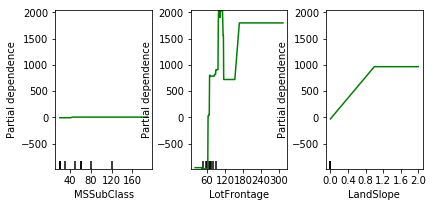

In [37]:
from sklearn.ensemble.partial_dependence import partial_dependence, plot_partial_dependence
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor()
gbr_model.fit(train_X, train_y)
plots = plot_partial_dependence(gbr_model, features=[1, 2, 8], X=train_X, feature_names=train_X.columns, grid_resolution=200)

The above PDP indicates no influence of the feature **MSSubClass**, but significant influence of **LotFrontage** feature

## <a id='section24'>Data Pipeline</a>
Data pipelines ensures cleaner code, fewer bugs, easier to productionize and offers more options for model testing.

Life of a data has the following steps 

- **Getting or Collection of Data** – Applications, APIs, File Transfers etc
- **Cleaning Data** – Data Transformers, Data Marts etc
- **Exploratory Analysis** – Analysis and Intelligence tools like Tableau, Qlik etc and Technologies like R, Python, GGPlot2, MatPlotLib etc.
- **Statistical Inferences** – Identifying statistically significant attributes and properties from the data
- **Reproducible Research** – Repeat the analysis and inferences on different sample set
- **Regression Models** – Find the nature of the data. Linear, Logistic, Bayesian etc
- **Machine Learning** – Classification and Clustering of data. Feature creation and selection. Naïve Bayes, Random Forests etc.
- **Recommendation Systems** – Demand predictions, Route optimization, Log analysis, Share of Shelf etc.

All the above activities are to be done in tandem. Some involves ETL processes, visualization tools, external storage units, external data sources independent of a single project etc.
To ensure data integrity and reproducibility, data pipeline processes and procedures are achieved in various ways. One such way is explained in this video.

Reference: We got to productionize what we build and almost always the results are expected at realtime. This video gives an idea on the big picture
<iframe width="560" height="315" src="https://www.youtube.com/embed/C6Abv87D5dU?rel=0&amp;controls=0&amp;showinfo=0" frameborder="0" allowfullscreen></iframe>'





In [38]:
from sklearn.pipeline import make_pipeline
pipeline = make_pipeline(SimpleImputer(), XGBRegressor())
pipeline.fit(X, y)
validation_predictions = pipeline.predict(val_X)

print("MAE " + str(mean_absolute_error(validation_predictions, val_y)))

/opt/conda/lib/python3.6/site-packages/xgboost/core.py:587: FutureWarning: Series.base is deprecated and will be removed in a future version
  if getattr(data, 'base', None) is not None and \
/opt/conda/lib/python3.6/site-packages/xgboost/core.py:588: FutureWarning: Series.base is deprecated and will be removed in a future version
  data.base is not None and isinstance(data, np.ndarray) \


[09:33:53] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
MAE 10484.860327482877


## <a id='section25'>Cross Validation</a>
In cross validation we run our modeling process on different subsets of the data to get multiple measures of model quality. A five fold experiment scheme from **Dan Becker**'s course
![5 Fold CV Scheme](https://i.stack.imgur.com/1fXzJ.png)

In [39]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipeline, X,y, scoring='neg_mean_absolute_error')
print(scores)

[09:33:53] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


/opt/conda/lib/python3.6/site-packages/sklearn/model_selection/_split.py:1978: FutureWarning: The default value of cv will change from 3 to 5 in version 0.22. Specify it explicitly to silence this warning.
  warnings.warn(CV_WARNING, FutureWarning)
/opt/conda/lib/python3.6/site-packages/xgboost/core.py:587: FutureWarning: Series.base is deprecated and will be removed in a future version
  if getattr(data, 'base', None) is not None and \
/opt/conda/lib/python3.6/site-packages/xgboost/core.py:587: FutureWarning: Series.base is deprecated and will be removed in a future version
  if getattr(data, 'base', None) is not None and \


[09:33:54] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


/opt/conda/lib/python3.6/site-packages/xgboost/core.py:587: FutureWarning: Series.base is deprecated and will be removed in a future version
  if getattr(data, 'base', None) is not None and \


[09:33:54] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[-15613.77419148 -17119.04381096 -17404.30878665]
